In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.svm import SVC

import joblib
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
data = np.load('processed_wdbc_engineered.npz')
X = data['X']
y = data['y']

print("✅ Engineered Data Loaded")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

✅ Engineered Data Loaded
Shape of X: (569, 39)
Shape of y: (569,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n✅ Data Split Successfully")
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


✅ Data Split Successfully
Train set: (455, 39) (455,)
Test set: (114, 39) (114,)


In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Support Vector Classifier (SVM)": SVC(probability=True, random_state=42)
}

c:\Users\Aayush Pradhan\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [15:12:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 170, number of negative: 285
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5909
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373626 -> initscore=-0.516691
[LightGBM] [Info] Start training from score -0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

c:\Users\Aayush Pradhan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Aayush Pradhan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Aayush Pradhan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


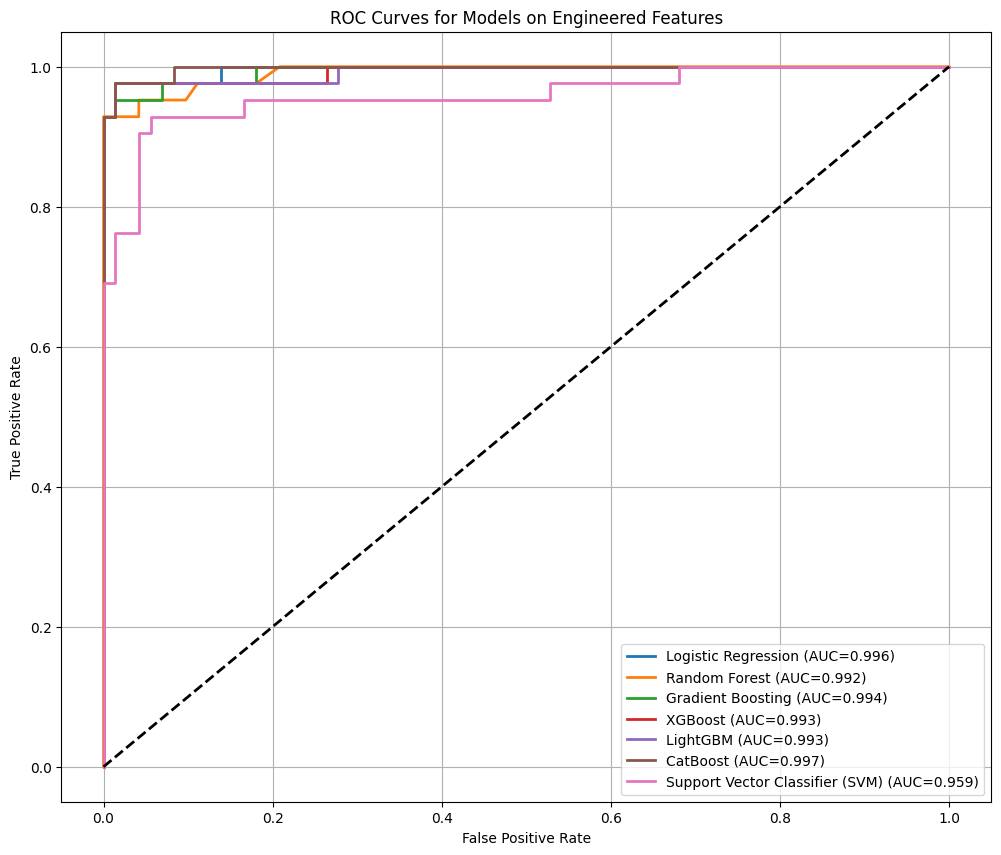

In [5]:
results = {}
plt.figure(figsize=(12, 10))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    }
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models on Engineered Features')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
leaderboard = pd.DataFrame(results).T.sort_values(by='ROC-AUC', ascending=False)
print("\n📋 Model Leaderboard:")
display(leaderboard)

best_model_name = leaderboard.index[0]
best_model = models[best_model_name]

print(f"\n✅ Best Model: {best_model_name}")


📋 Model Leaderboard:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
CatBoost,0.964912,1.0,0.904762,0.950000,0.997354
Logistic Regression,0.973684,1.0,0.928571,0.962963,0.996032
Gradient Boosting,0.964912,1.0,0.904762,0.950000,0.993717
XGBoost,0.964912,1.0,0.904762,0.950000,0.993056
LightGBM,0.964912,1.0,0.904762,0.950000,0.992725
Random Forest,0.973684,1.0,0.928571,0.962963,0.991898
Support Vector Classifier (SVM),0.631579,0.0,0.000000,0.000000,0.958995



✅ Best Model: CatBoost


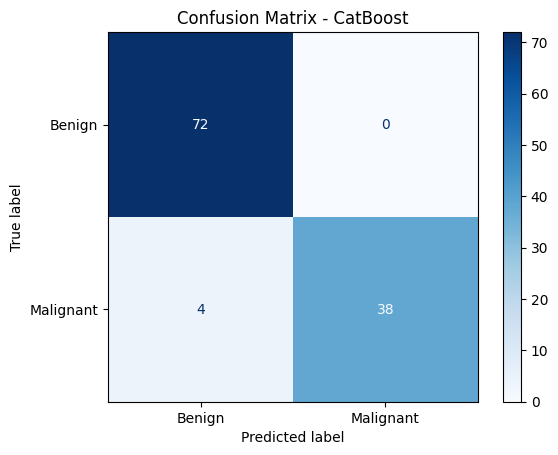

In [9]:
# Confusion Matrix for Best Model
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

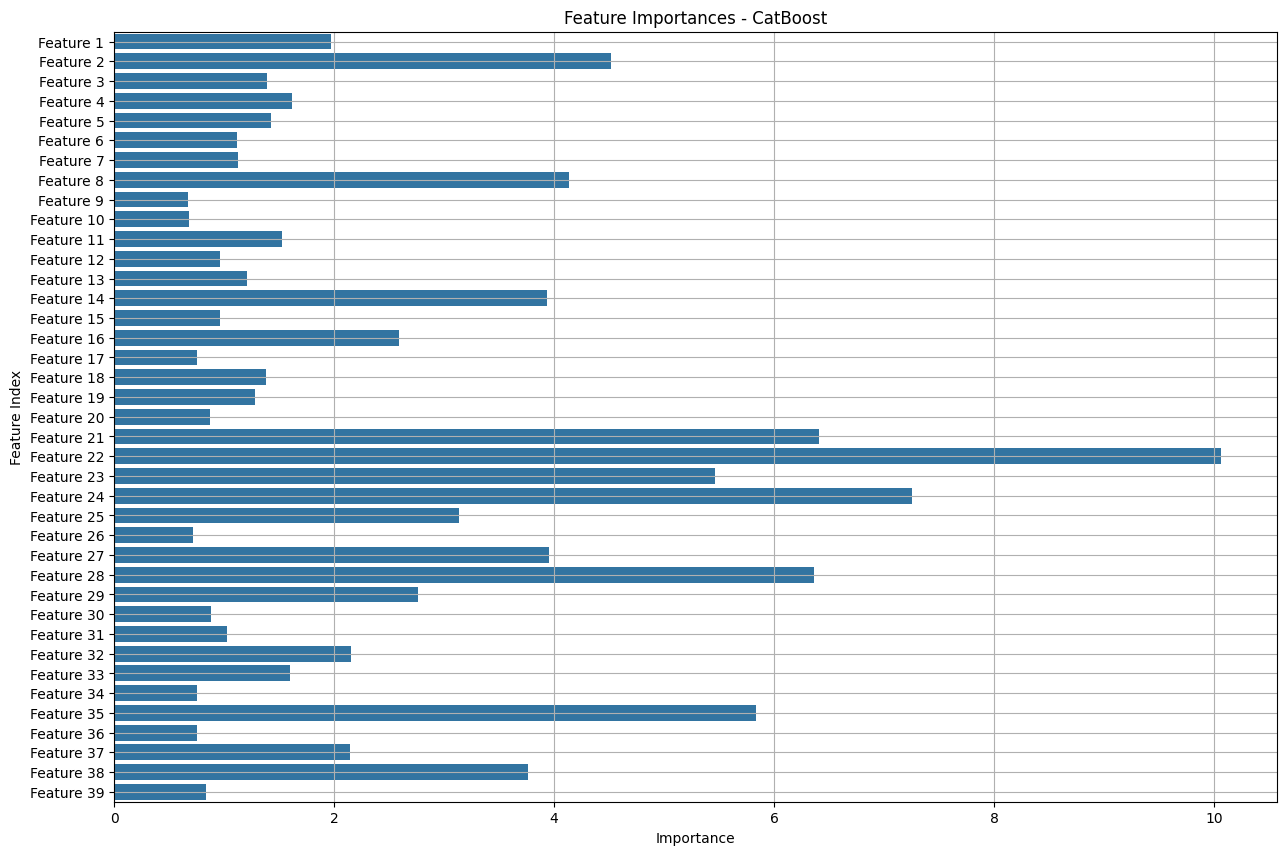

In [13]:
# 10. Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(15,10))
    sns.barplot(x=best_model.feature_importances_, y=[f'Feature {i+1}' for i in range(X.shape[1])])
    plt.title(f'Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature Index')
    plt.grid(True)
    plt.show()
else:
    print("\nℹ️ Best model does not have feature importances (likely SVM or Logistic Regression).")


In [14]:
# Cross-Validation Score for Best Model
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kfold, scoring='roc_auc')

print(f"\n✅ Cross-Validation ROC-AUC Scores (5 folds): {cv_scores}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


✅ Cross-Validation ROC-AUC Scores (5 folds): [0.99803472 0.99213888 0.98247354 0.99801587 0.99463447]
Mean ROC-AUC: 0.9931 ± 0.0057


In [15]:
# Save Best Model
joblib.dump(best_model, 'best_model_engineered.pkl')
print("\n✅ Best Model Saved as 'best_model_engineered.pkl'")


✅ Best Model Saved as 'best_model_engineered.pkl'


## Threshold Optimization

✅ Optimal Threshold Found: 0.1939


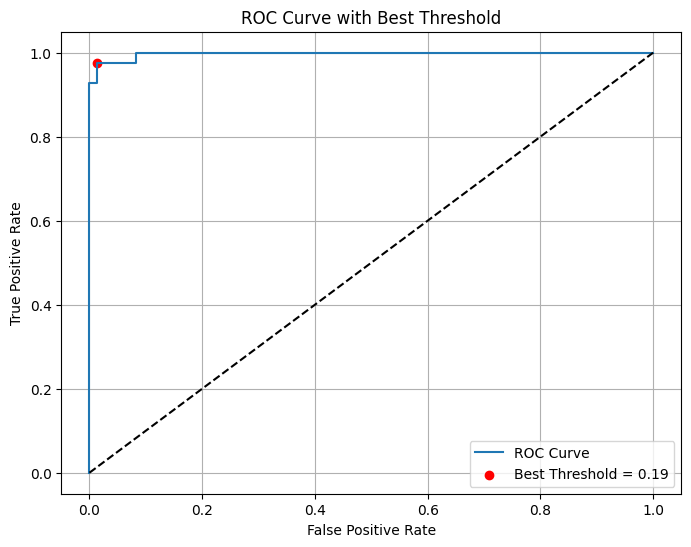


📋 Model Performance at Optimized Threshold:
Accuracy: 0.9825
Precision: 0.9762
Recall: 0.9762
F1-Score: 0.9762


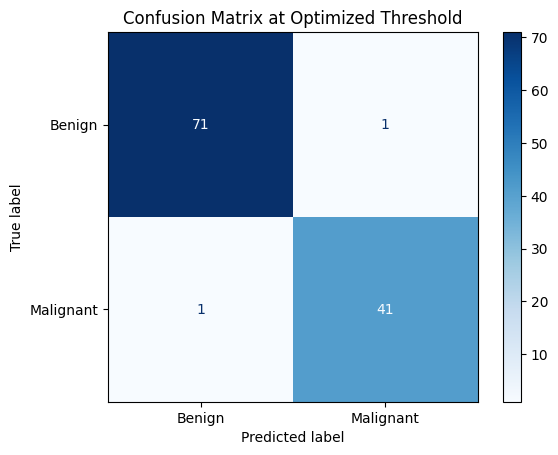

In [16]:
best_model = joblib.load('best_model_engineered.pkl')

y_pred_proba = best_model.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Youden's J Statistic
youden_index = tpr - fpr
best_threshold_index = np.argmax(youden_index)
best_threshold = thresholds[best_threshold_index]

print(f"✅ Optimal Threshold Found: {best_threshold:.4f}")

# 5. Plot ROC with Best Threshold Marked
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.scatter(fpr[best_threshold_index], tpr[best_threshold_index], color='red', label=f'Best Threshold = {best_threshold:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Best Threshold')
plt.legend()
plt.grid(True)
plt.show()

# 6. Evaluate Model at Best Threshold
y_pred_best_thresh = (y_pred_proba >= best_threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(y_test, y_pred_best_thresh)
prec = precision_score(y_test, y_pred_best_thresh)
rec = recall_score(y_test, y_pred_best_thresh)
f1 = f1_score(y_test, y_pred_best_thresh)

print("\n📋 Model Performance at Optimized Threshold:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

# 7. Confusion Matrix at Best Threshold
cm = confusion_matrix(y_test, y_pred_best_thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix at Optimized Threshold')
plt.grid(False)
plt.show()


## SHAP Feature Selection

In [18]:
import shap

In [19]:
data = np.load('processed_wdbc_engineered.npz')
X_full = data['X']
y_full = data['y']

best_model = joblib.load('best_model_engineered.pkl')

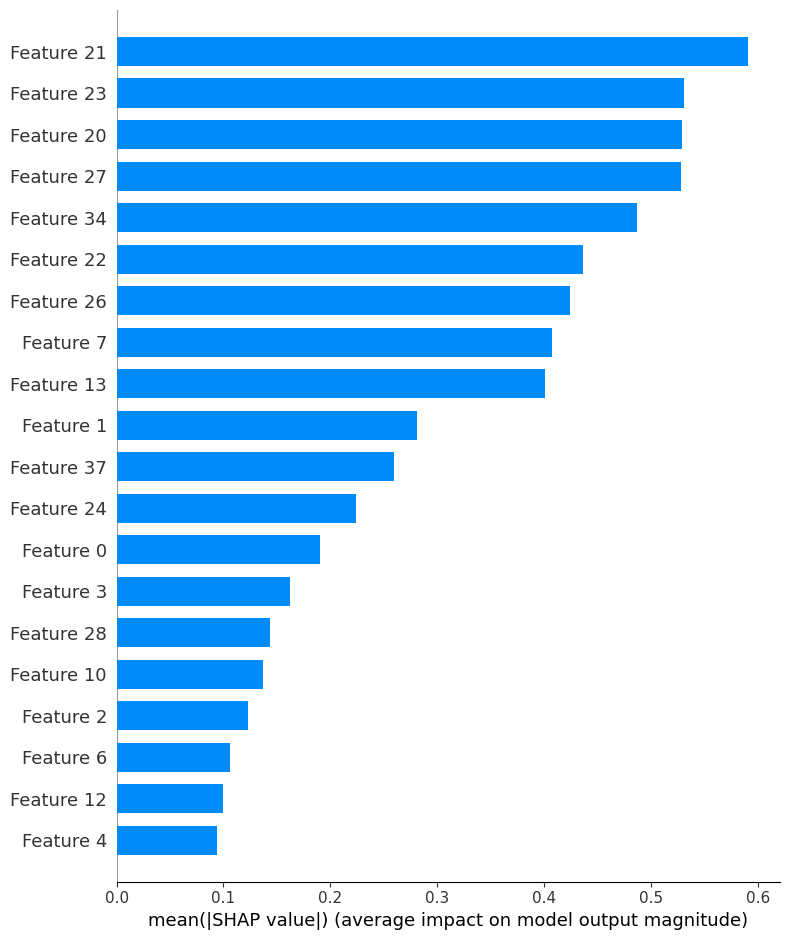

In [20]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(best_model)  
shap_values = explainer.shap_values(X_full)

# Global Feature Importance Plot
shap.summary_plot(shap_values, X_full, plot_type='bar', show=True)

In [24]:
# Identify Top N Important Features
mean_shap = np.abs(shap_values).mean(axis=0)
top_n = 10
top_feature_indices = np.argsort(mean_shap)[-top_n:]

print(f"\n✅ Top {top_n} Feature Indices Selected:", top_feature_indices)


✅ Top 10 Feature Indices Selected: [ 1 13  7 26 22 34 27 20 23 21]


In [25]:
X_selected = X_full[:, top_feature_indices]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y_full, test_size=0.2, random_state=42, stratify=y_full
)

In [26]:
best_model_selected = best_model.__class__(**best_model.get_params())  
best_model_selected.fit(X_train_sel, y_train_sel)

# Evaluate
y_pred_sel = best_model_selected.predict(X_test_sel)
y_pred_proba_sel = best_model_selected.predict_proba(X_test_sel)[:,1]

print("\n📋 Model Performance (Using Selected Top Features Only):")
print(f"Accuracy: {accuracy_score(y_test_sel, y_pred_sel):.4f}")
print(f"Precision: {precision_score(y_test_sel, y_pred_sel):.4f}")
print(f"Recall: {recall_score(y_test_sel, y_pred_sel):.4f}")
print(f"F1-Score: {f1_score(y_test_sel, y_pred_sel):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_sel, y_pred_proba_sel):.4f}")


📋 Model Performance (Using Selected Top Features Only):
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1-Score: 0.9500
ROC-AUC: 0.9960


## Error Analysis


✅ False Positives (Predicted Malignant, Actually Benign): 1
✅ False Negatives (Predicted Benign, Actually Malignant): 1


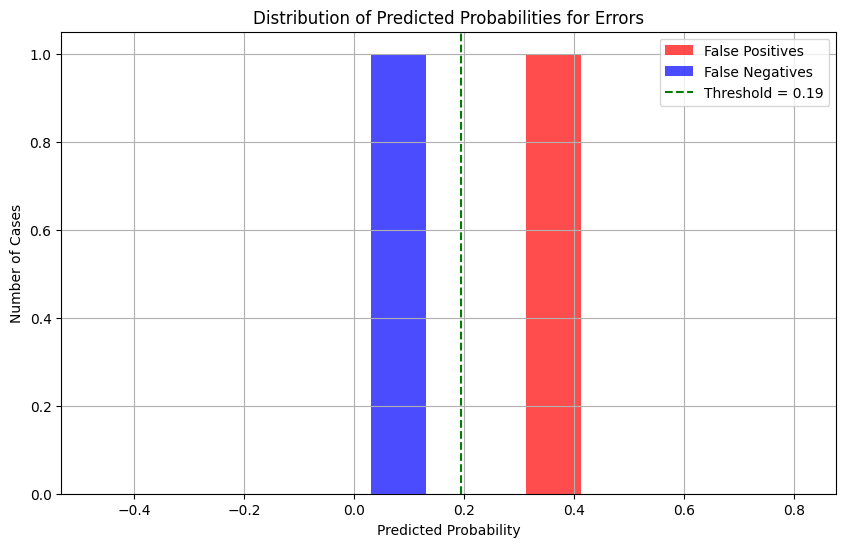

In [28]:
data = np.load('processed_wdbc_engineered.npz')
X = data['X']
y = data['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model = joblib.load('best_model_engineered.pkl')

y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Use previously optimized threshold 
optimal_threshold = 0.1939
y_pred_final = (y_pred_proba >= optimal_threshold).astype(int)

# Identify Errors
false_positives = (y_pred_final == 1) & (y_test == 0)
false_negatives = (y_pred_final == 0) & (y_test == 1)

print(f"\n✅ False Positives (Predicted Malignant, Actually Benign): {false_positives.sum()}")
print(f"✅ False Negatives (Predicted Benign, Actually Malignant): {false_negatives.sum()}")

# Create a DataFrame for easy analysis
X_test_df = pd.DataFrame(X_test)
X_test_df['True_Label'] = y_test
X_test_df['Predicted_Label'] = y_pred_final
X_test_df['Predicted_Prob'] = y_pred_proba

# Plot Predicted Probabilities
plt.figure(figsize=(10,6))
plt.hist(X_test_df.loc[false_positives, 'Predicted_Prob'], bins=10, alpha=0.7, label='False Positives', color='red')
plt.hist(X_test_df.loc[false_negatives, 'Predicted_Prob'], bins=10, alpha=0.7, label='False Negatives', color='blue')
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Threshold = {optimal_threshold:.2f}')
plt.title('Distribution of Predicted Probabilities for Errors')
plt.xlabel('Predicted Probability')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()